In [1]:
import scarf
import scarf.plotting as splt

scarf.configure_output(level='WARNING', progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA'
)

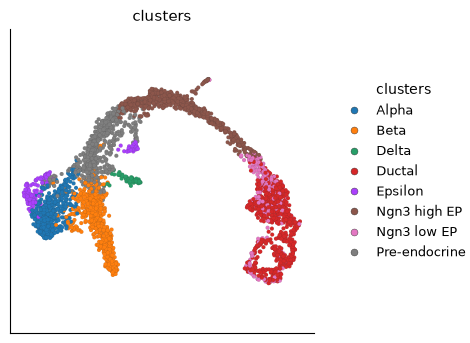

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
)

In [4]:
ds.run_cell_cycle_scoring()

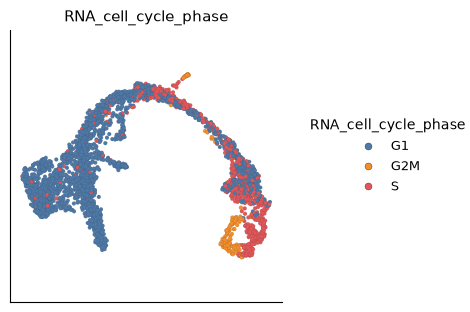

In [5]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_cycle_phase',
)

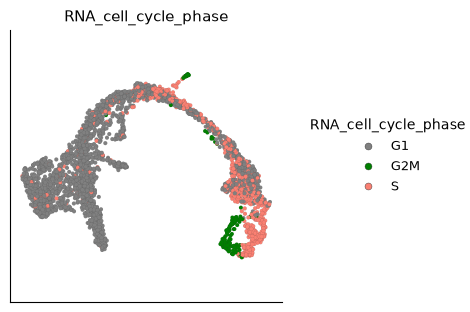

In [6]:
color_key = {
    'G1': 'grey',
    'S': 'salmon',
    'G2M': 'green',
}

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_cycle_phase',
    categorical_scale=splt.CategoricalScale(palette=color_key),
)

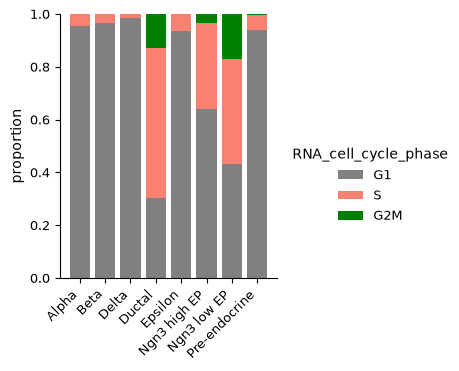

In [7]:
ds.plots.composition(
    category_by='RNA_cell_cycle_phase',
    sample_by='clusters',
    kind='stacked',
    categorical_scale=splt.CategoricalScale(
        palette=color_key,
        order=['G1', 'S', 'G2M'],
    ),
)

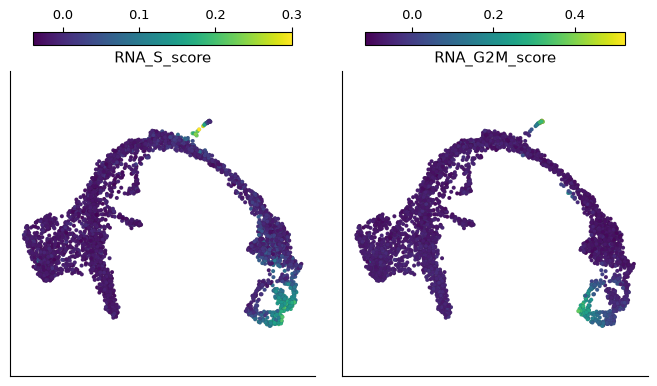

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['RNA_S_score', 'RNA_G2M_score'],
)

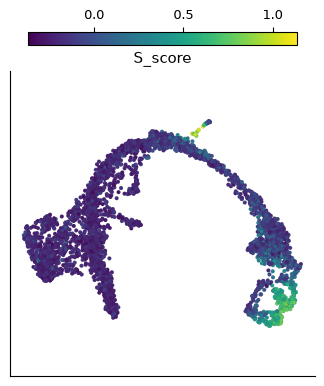

In [9]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='S_score',
)

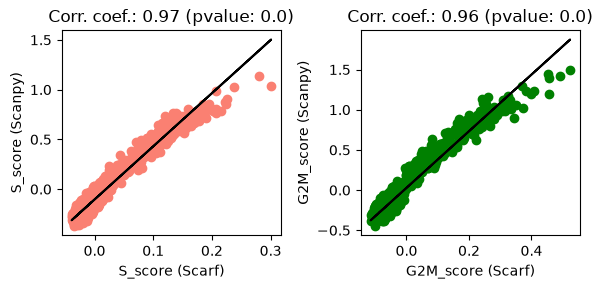

In [10]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, axis  = plt.subplots(1, 2, figsize=(6,3))
for n,i in enumerate(['S_score', 'G2M_score']):
    x = ds.cells.fetch(f"RNA_{i}")
    y = ds.cells.fetch(i)
    res = linregress(x, y)
    
    ax = axis[n]
    ax.scatter(x, y, color=color_key[i.split('_')[0]])
    ax.plot(x, res.intercept + res.slope*x, label='fitted line', c='k')
    ax.set_xlabel(f"{i} (Scarf)")
    ax.set_ylabel(f"{i} (Scanpy)")
    ax.set_title(f"Corr. coef.: {round(res.rvalue, 2)} (pvalue: {res.pvalue})")

plt.tight_layout()
plt.show()